# Overlap error of the L=100 production walkers

The runs in `cpmc_L100/L100_U8` are production MPS-CPMC (`mps_cpmc_gpu.py`, on an A100). The setup is $L=100$, $U=8$, half filling, 400 walkers and 60 + 200 blocks, with DMRG trials at bond $\chi_T=8$, 16 and 32. The walkers are converted at bond $\chi_w=32$ per spin channel, with the gate circuit and kept counts frozen on the trial's natural-orbital determinant. Every block's walkers were saved.

This notebook takes a subsample of those walkers and asks two questions: **how far is the overlap $O=\langle\Psi_T|\phi\rangle$ that production computes from the exact one, and where does the difference come from?** Every overlap below is computed with `mps_cpmc_gpu`'s own functions (`make_gpu_ops(...).overlaps`), on the same trial, plans and bond plans the run used. Each conversion differs from the one before it in one thing:

| conversion | walker QR | linear algebra | truncation |
|---|---|---|---|
| **production** | CholeskyQR2 | batched (the GPU layout) | $\chi_w=32$, kept counts frozen on the reference (`plan_bonds`) |
| production, Householder QR | Householder (trot's `_qr`) | batched | the same |
| production, per-sector loop | Householder | native (`channel_mps`, as in `mps_cpmc_new.py`) | the same |
| own counts | Householder | batched | $\chi_w=32$, each walker's own counts (production's `dynamic_chi`, inside the untruncated bonds) |
| **full** | Householder | batched | none: the untruncated fixed plan, the reference |
| wider | Householder | batched | none, and a wider plan (purity tolerance `EPS_WIDER`); on a few walkers, to check that "full" has converged |

So production's error $\delta O=|O_{\rm prod}/O_{\rm full}-1|$ splits into five sources, each the ratio of neighbouring rows:

1. the walker QR;
2. the batched linear algebra;
3. the frozen particle counts: production against own counts, both at $\chi_w=32$;
4. the bond truncation: own counts against full;
5. the fixed blocks: full against wider.

Why "full" and not a wider plan as the reference:

- The natural-orbital plan already uses blocks of up to 8 sites at $L=100$, and the walkers need at most 5–7 (see the checks). So the untruncated fixed-plan gMPS is exact up to the purity tolerance.
- A plan much wider still would have bonds of 512, and contracting that against the trial is too costly here. The "wider" row checks the reference on a subsample instead.

Caveats:

- The saved walkers are orthonormal already (they are stored after the block's QR), so the QR row can only show roundoff. What CholeskyQR2 did to ill-conditioned walkers *during* the propagation can't be seen from snapshots.
- Everything runs on the CPU, so the GPU's own roundoff isn't reproduced. The run's start-up self-check found the device conversion within $3\times10^{-13}$ of the NumPy one.

In [9]:
from pathlib import Path

# ---- the production runs (mps_cpmc_gpu.py): analysed if their walker file is present
RUN_DIR = Path("cpmc_L100/L100_U8")
RUNS = [f"L100_U8_T{chi}_w32_NOplan_NOstart_s1234" for chi in (16,)]
# ---- subsample
SNAPSHOTS = 8                 # evenly spaced sampling-phase snapshots per run, plus tau = 0
WALKERS = 100                 # the first walkers of each snapshot (after the comb they all weigh the same)
CHUNK = 20                    # walkers per jitted call (WALKERS and WIDER_WALKERS should be multiples)
EPS_WIDER, WIDER_WALKERS = 1e-12, 20   # convergence check of the reference: a wider NO plan on fewer walkers
# ---- trials: the run's export in RUN_DIR if present, else rebuilt with production's DMRG and cached here
TRIAL_CACHE = Path("walker_overlap_error_data/trial_cache")
# ---- every stage is cached in DATA_DIR; recomputed if missing or RERUN
DATA_DIR = Path("walker_overlap_error_data")
RERUN = False

In [10]:
import hashlib
import json
import struct
import sys
import time
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_gpu.py
import mps_cpmc_gpu as g
from trot.ham.hubbard import HamHubbard
from trot.prop.hubbard_cpmc_ops import _build_prop_ctx

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))
DATA_DIR.mkdir(exist_ok=True)
# at L=100 every conversion variant takes minutes to compile on a CPU: keep the compiled programs
jax.config.update("jax_compilation_cache_dir", str((DATA_DIR / "jax_cache").resolve()))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 1.0)


def save(fig, name):
    path = DATA_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")


def cached(path, compute):
    # np.load of the file at path, computing and saving it first if missing or RERUN
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **compute())
        print(f"computed {path.name} in {time.perf_counter() - start:.0f} s")
    return dict(np.load(path))


def npz_member(path, name):
    # memory-map one array of an uncompressed .npz (np.savez) without reading the others: the walker files are 8 GB
    with zipfile.ZipFile(path) as z:
        info = z.getinfo(f"{name}.npy")
        if info.compress_type != zipfile.ZIP_STORED:
            raise ValueError(f"{name} is compressed; load it with np.load")
    with open(path, "rb") as fh:
        fh.seek(info.header_offset)
        n_name, n_extra = struct.unpack("<HH", fh.read(30)[26:30])
        fh.seek(info.header_offset + 30 + n_name + n_extra)
        version = np.lib.format.read_magic(fh)
        read = np.lib.format.read_array_header_1_0 if version == (1, 0) else np.lib.format.read_array_header_2_0
        shape, fortran, dtype = read(fh)
        offset = fh.tell()
    return np.memmap(path, dtype=dtype, mode="r", shape=shape, offset=offset, order="F" if fortran else "C")

## Runs, trials and plans

For each run, the notebook reads its config, energies and plan reference from the walker file. From the 8 GB walker arrays it memory-maps only the subsample: snapshot 0 (the start, every walker equal to the reference) and `SNAPSHOTS` evenly spaced sampling-phase snapshots, `WALKERS` walkers each.

- **Trial.** The run exported its DMRG trial to the cluster (`trial_file` in its config). If that file has been copied into `RUN_DIR` it is used. Otherwise the trial is rebuilt with production's own `load_or_run_trial` (same $L$, $U$, $\chi_T$, sweeps and seed), and its DMRG energy must match the run's `E_DMRG`.
- **Plans.** The gate circuit is `make_orbital_plan(reference, "adaptive", EPS)` and the kept counts `plan_bonds(reference, plan, CHI_PROP)`, on the reference determinant the run stored. That is exactly what `mps_cpmc_gpu.build` does.
- **Checks.** The trial's natural orbitals must span the stored reference, and the saved walkers must be orthonormal.

In [11]:
RUN = {}
for tag in RUNS:
    path = RUN_DIR / f"{tag}_walkers.npz"
    if not path.exists():
        print(f"{tag}: no walker file in {RUN_DIR}, skipped")
        continue
    z = np.load(path)
    cfg = json.loads(str(z["config"]))
    L, n_up, n_dn, U, chi_T = cfg["L"], cfg["N_UP"], cfg["N_DN"], cfg["U"], cfg["DMRG_CHI_T"]
    tau = z["tau_snapshots"]
    samp = np.flatnonzero(np.arange(len(tau)) > cfg["N_EQL"])
    snaps = np.concatenate([[0], samp[np.unique(np.linspace(0, len(samp) - 1, SNAPSHOTS).round().astype(int))]])
    walk = tuple(np.stack([np.array(npz_member(path, s)[j, :WALKERS]) for j in snaps]) for s in ("up", "dn"))

    export = RUN_DIR / Path(cfg["trial_file"]).name
    if export.exists():
        t = np.load(export)
        T, q, e_dmrg = [t[f"T{i}"] for i in range(L)], tuple(t[f"q{i}"] for i in range(L + 1)), float(t["e_dmrg"])
        source = f"the run's export {export.name}"
    else:
        c = g.Config(L=L, n_up=n_up, n_down=n_dn, hopping=cfg["T"], interaction=U, trial_chi=chi_T,
                     dmrg_sweeps=cfg["DMRG_SWEEPS"], dmrg_seed=0, trial_cache=str(TRIAL_CACHE))
        T, q, e_dmrg = g.load_or_run_trial(c)
        source = "rebuilt with production's DMRG"
    # a DMRG state is defined up to its global sign (a rebuilt trial can be minus the run's), so every cached
    # overlap carries the fingerprint of the trial it was computed with
    trial_id = hashlib.sha1(b"".join(np.ascontiguousarray(A).tobytes() for A in T)).hexdigest()[:10]
    ref = (z["reference_up"], z["reference_dn"])
    plans = [g.make_orbital_plan(C, cfg["orbital_plan"], cfg["EPS"]) for C in ref]
    run = dict(cfg=cfg, trial_id=trial_id, tau=tau[snaps], snaps=snaps, walk=walk, trial=(T, q), ref=ref, plans=plans,
               bonds=[g.plan_bonds(C, p, cfg["CHI_PROP"], 0.0) for C, p in zip(ref, plans)],
               pad=[g.plan_bonds(C, p, None, 0.0) for C, p in zip(ref, plans)],
               wider=[g.make_orbital_plan(C, "adaptive", EPS_WIDER) for C in ref],
               energies=z["energies"], weights=z["weights"], tau_blocks=z["tau_blocks"])
    RUN[tag] = run

    # checks: the trial is the run's, its natural orbitals span the stored reference, the walkers are orthonormal
    no = [g.natural_orbitals(x, n)[0] for x, n in zip(g.one_rdm(T), (n_up, n_dn))]
    span = max(np.abs(a @ a.T - b @ b.T).max() for a, b in zip(no, ref))
    orth = max(np.abs(np.einsum("swli,swlj->swij", W, W) - np.eye(W.shape[-1])).max() for W in walk)
    print(f"{tag}: trial chi_T={chi_T} from {source} (fingerprint {trial_id}), E_DMRG {e_dmrg:.12f} (run: {cfg['E_DMRG']:.12f}, "
          f"diff {abs(e_dmrg - cfg['E_DMRG']):.1e})")
    print(f"    trial NOs vs stored reference: max |P_NO - P_ref| {span:.1e};  walkers orthonormal to {orth:.1e};  "
          f"{len(snaps)} snapshots (tau {', '.join(f'{x:g}' for x in tau[snaps])}) x {WALKERS} walkers")
    print(f"    plan: max B {[int(p.block_sizes.max()) for p in plans]}, untruncated bond {[b.max_bond for b in run['pad']]}, "
          f"chi_w = {cfg['CHI_PROP']} discards {run['bonds'][0].reference_discarded_weight:.1e} on the reference;  "
          f"wider plan (eps {EPS_WIDER:.0e}): max B {[int(p.block_sizes.max()) for p in run['wider']]}")
    print(f"    CPMC energy {cfg['E_CPMC']:.5f} +- {cfg['E_CPMC_ERR']:.5f}")

L100_U8_T16_w32_NOplan_NOstart_s1234: trial chi_T=16 from the run's export dmrg_trial_L100_U8_chi16.npz (fingerprint 978b70e2f3), E_DMRG -32.364238072212 (run: -32.364238072212, diff 0.0e+00)
    trial NOs vs stored reference: max |P_NO - P_ref| 2.3e-15;  walkers orthonormal to 1.7e-15;  9 snapshots (tau 0, 12.2, 17.8, 23.6, 29.2, 35, 40.6, 46.4, 52) x 100 walkers
    plan: max B [8, 8], untruncated bond [128, 128], chi_w = 32 discards 1.7e-11 on the reference;  wider plan (eps 1e-12): max B [9, 9]
    CPMC energy -32.40627 +- 0.00304


## Overlaps, every way

For each run, each conversion of the table in the introduction is built with `mps_cpmc_gpu.make_gpu_ops` from the run's own trial, plans and bond plans. Its `overlaps` (walker QR, conversion, factorized walker–trial contraction, times $\det R$) is jitted and applied to the subsample. Every stage is cached per run and conversion.

**Cost.** Compilation dominates: at $L=100$ each conversion takes 2–4 minutes to compile on this laptop, then 25–40 ms per walker. The wider plan (bond 256) costs more per walker, so it runs on `WIDER_WALKERS` walkers only. The compiled programs are kept in `DATA_DIR/jax_cache`, so a rerun skips most of it.

The walker QR isn't compiled separately. Its effect is measured directly: production's CholeskyQR2 (`make_batch_qr("cholesky")`) against Householder (`"native"`) on the same walkers, comparing $Q$ and $\det R$.

In [12]:
VARIANTS = {   # name: (plans, bond plans, walker QR, linear algebra, per-walker kept counts)
    "prod": ("plans", "bonds", "cholesky", "batched", False),        # the run
    "prod_native": ("plans", "bonds", "native", "native", False),     # per-sector loop, as mps_cpmc_new.py
    "own": ("plans", "pad", "native", "batched", True),               # each walker's own counts inside the untruncated bonds
    "full": ("plans", None, "native", "batched", False),              # untruncated fixed plan: the reference
    "wider": ("wider", None, "native", "batched", False),             # wider plan: checks the reference
}


def overlap_fn(run, name):
    plans, bonds, qr, linalg, own = VARIANTS[name]
    cfg, (T, q) = run["cfg"], run["trial"]
    prop = _build_prop_ctx(HamHubbard(h1=jnp.asarray(g.hopping_matrix(cfg["L"], cfg["T"])), u=cfg["U"]), cfg["DT"])
    ops = g.make_gpu_ops(*run[plans], *(run[bonds] if bonds else (None, None)), T, q, (), prop, linalg=linalg,
                         walker_qr=qr, spin_batch=True, energy="dense", dynamic_chi=cfg["CHI_PROP"] if own else None)
    f = jax.jit(ops.overlaps)
    return lambda ca, cb: np.asarray(f(jnp.asarray(ca), jnp.asarray(cb), ops.data))


def evaluate(run, name):
    n = WIDER_WALKERS if name == "wider" else WALKERS
    f, (up, dn) = overlap_fn(run, name), run["walk"]
    return dict(O=np.stack([np.concatenate([f(up[j, i:min(i + CHUNK, n)], dn[j, i:min(i + CHUNK, n)])
                                            for i in range(0, n, CHUNK)]) for j in range(len(run["snaps"]))]))


def qr_and_blocks(run):
    # production's CholeskyQR2 against Householder on the same walkers; the fixed plans' kept fidelity det(R[occ])^2
    chol, house = g.make_batch_qr("cholesky"), g.make_batch_qr("native")
    out = dict(dQ=np.zeros((len(run["snaps"]), WALKERS, 2)), ddet=np.zeros((len(run["snaps"]), WALKERS, 2)),
               F_full=np.zeros((len(run["snaps"]), WALKERS, 2)), F_wider=np.zeros((len(run["snaps"]), WALKERS, 2)))
    for s, W in enumerate(run["walk"]):
        for j in range(len(run["snaps"])):
            (Qc, dc), (Qh, dh) = (tuple(np.asarray(x) for x in f(jnp.asarray(W[j]))) for f in (chol, house))
            out["dQ"][j, :, s] = np.abs(Qc - Qh).max(axis=(1, 2))
            out["ddet"][j, :, s] = np.abs(dc / dh - 1)
            for key, plan in (("F_full", run["plans"][s]), ("F_wider", run["wider"][s])):
                for w, Q in enumerate(Qh):
                    _, rows = g.channel_angles(Q, plan, xp=np)
                    out[key][j, w, s] = np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)])) ** 2
    return out


for tag, run in RUN.items():
    stem = DATA_DIR / f"{tag}_trial{run['trial_id']}_n{SNAPSHOTS}x{WALKERS}"
    run["O"] = {}
    for name in VARIANTS:
        suffix = f"_{name}{WIDER_WALKERS}_eps{EPS_WIDER:.0e}" if name == "wider" else f"_{name}"
        run["O"][name] = cached(Path(f"{stem}{suffix}.npz"), lambda run=run, name=name: evaluate(run, name))["O"]
    run.update(cached(Path(f"{stem}_qr_blocks_eps{EPS_WIDER:.0e}.npz"), lambda run=run: qr_and_blocks(run)))
    print(f"{tag}: overlaps of {WALKERS} walkers x {len(run['snaps'])} snapshots, the wider plan on {WIDER_WALKERS}")

computed L100_U8_T16_w32_NOplan_NOstart_s1234_trial978b70e2f3_n8x100_prod.npz in 176 s
L100_U8_T16_w32_NOplan_NOstart_s1234: overlaps of 100 walkers x 9 snapshots, the wider plan on 20


### Checks

- **The overlaps are production's.** At $\tau=0$ every walker is the plan reference, whose natural-orbital determinant the plan (and `plan_bonds`) was built on. There, all conversions must agree to the purity tolerance.
- **Own counts are the walker's own.** Production's `dynamic_chi` path, which keeps each walker's $\chi_w$ largest values within the untruncated bonds, must give the same channel state as `channel_mps_host(Q, plan, plan_bonds(Q, plan, χ_w))`, i.e. `plan_bonds` run on the walker itself. This is checked eagerly on one walker (it takes about a minute at $L=100$).
- **Every conversion gives the reference's sign.** A sign that differs for some walkers would be a real error. A sign that differs for all of them means two different trials were mixed: a DMRG state is only defined up to its global sign, and a rebuilt trial can come out as minus the run's. That's why every cache name carries the trial's fingerprint.
- **The saved walkers are already orthonormal,** so the two QRs can only differ by roundoff.

In [13]:
r = lambda a, b: np.abs(a / b - 1)
for tag, run in RUN.items():
    O = run["O"]
    flips = {k: int(np.sum(np.sign(O[k]) != np.sign(O["full"][:, :O[k].shape[1]]))) for k in O if k != "full"}
    print(f"{tag}: walkers whose overlap sign differs from the reference's: {flips}  (must all be 0)")
    start = max(r(O[k][0], O["full"][0]).max() for k in ("prod", "prod_native", "own"))
    print(f"{tag}: tau = 0 (every walker is the reference): max |O / O_full - 1| over the conversions {start:.1e};  "
          f"QR: max |Q_chol - Q_house| {run['dQ'].max():.1e}, max |det_chol / det_house - 1| {run['ddet'].max():.1e}")

# own counts: production's dynamic_chi converter against plan_bonds run on one walker, eagerly
tag, run = next(iter(RUN.items()))
cfg = run["cfg"]
Q = [np.linalg.qr(W[-1, 0])[0] for W in run["walk"]]
conv = g.make_converter(*run["plans"], *run["pad"], linalg="batched", spin_batch=True, dynamic_chi=cfg["CHI_PROP"])
own = conv.convert(jnp.asarray(Q[0]), jnp.asarray(Q[1]))
for s in (0, 1):
    host, _, _ = g.channel_mps_host(Q[s], run["plans"][s], g.plan_bonds(Q[s], run["plans"][s], cfg["CHI_PROP"], 0.0))
    a, b = [np.asarray(t) for t in own[s]], host
    ab, aa, bb = (g.mps_overlap_host(x, y) for x, y in ((a, b), (a, a), (b, b)))
    print(f"{tag}, last snapshot, walker 0, spin {'↑↓'[s]}: dynamic_chi vs plan_bonds on the walker: 1 - fidelity "
          f"{1 - ab ** 2 / (aa * bb):.1e}")

L100_U8_T16_w32_NOplan_NOstart_s1234: walkers whose overlap sign differs from the reference's: {'prod': 0, 'prod_native': 0, 'own': 0, 'wider': 0}  (must all be 0)
L100_U8_T16_w32_NOplan_NOstart_s1234: tau = 0 (every walker is the reference): max |O / O_full - 1| over the conversions 3.2e-08;  QR: max |Q_chol - Q_house| 1.4e-15, max |det_chol / det_house - 1| 6.7e-15
L100_U8_T16_w32_NOplan_NOstart_s1234, last snapshot, walker 0, spin ↑: dynamic_chi vs plan_bonds on the walker: 1 - fidelity 1.3e-15
L100_U8_T16_w32_NOplan_NOstart_s1234, last snapshot, walker 0, spin ↓: dynamic_chi vs plan_bonds on the walker: 1 - fidelity 2.0e-15


## How big is production's overlap error, and where does it come from?

Sampling-phase snapshots only; snapshot 0, the start, is left out. Each row is $|O_a/O_b-1|$ per walker, both spins together:

| row | $a$ | $b$ | measures |
|---|---|---|---|
| **production, total** | production | full | everything production does differently from the untruncated conversion |
| linear algebra (and QR) | production | per-sector loop | the GPU layout (batched sector factorisations) and CholeskyQR2 |
| truncation, own counts | own counts | full | truncating to $\chi_w$ with each walker's best counts |
| truncation, frozen counts | per-sector loop | full | production's truncation: counts frozen on the reference |
| fixed blocks | full | wider | the reference's own error (on `WIDER_WALKERS` walkers per snapshot) |
| **production vs wider** | production | wider | the best estimate of production's error against the exact overlap |

The fixed plan's kept fidelity $1-F=1-\det R[\mathrm{occ},:]^2$ per walker is shown as well: the norm the untruncated conversion drops.

In [14]:
q = lambda x: f"{np.median(x):9.1e} {np.percentile(x, 99):9.1e} {x.max():9.1e}"
SOURCES = [("production, total", "prod", "full"), ("linear algebra (and QR)", "prod", "prod_native"),
           ("truncation, own counts", "own", "full"), ("truncation, frozen counts", "prod_native", "full"),
           ("fixed blocks", "full", "wider"), ("production vs wider", "prod", "wider")]


def source(run, a, b):
    # |O_a / O_b - 1| over the sampling snapshots, restricted to the walkers both have
    n = min(run["O"][a].shape[1], run["O"][b].shape[1])
    return r(run["O"][a][1:, :n], run["O"][b][1:, :n]).ravel()


for tag, run in RUN.items():
    cfg = run["cfg"]
    print(f"{tag}  (chi_T = {cfg['DMRG_CHI_T']}, chi_w = {cfg['CHI_PROP']}; sampling phase, "
          f"{len(run['snaps']) - 1} snapshots)")
    print(f"  {'source':28s} {'median':>9s} {'99%':>9s} {'max':>9s}")
    for label, a, b in SOURCES:
        print(f"  {label:28s} {q(source(run, a, b))}")
    loss = 1 - run["F_full"][1:].prod(axis=2).ravel()
    print(f"  {'fixed plan 1-F per walker':28s} {q(np.clip(loss, 0, None))}   (wider plan: max "
          f"{np.clip(1 - run['F_wider'][1:].prod(axis=2), 0, None).max():.1e})")
    print(f"  walker |O| (normalised): median {np.median(np.abs(run['O']['full'][1:])):.1e}, "
          f"min {np.abs(run['O']['full'][1:]).min():.1e}\n")

L100_U8_T16_w32_NOplan_NOstart_s1234  (chi_T = 16, chi_w = 32; sampling phase, 8 snapshots)
  source                          median       99%       max
  production, total              6.9e-11   5.3e-10   2.0e-09
  linear algebra (and QR)        8.6e-11   6.0e-10   2.0e-09
  truncation, own counts         8.1e-11   7.0e-10   1.1e-09
  truncation, frozen counts      5.7e-11   5.6e-10   8.9e-10
  fixed blocks                   9.6e-12   1.7e-10   2.8e-10
  production vs wider            6.8e-11   4.7e-10   5.2e-10
  fixed plan 1-F per walker      0.0e+00   2.8e-14   3.1e-12   (wider plan: max 1.2e-14)
  walker |O| (normalised): median 3.2e-09, min 9.4e-13



The same numbers as plots:

- production's overlap error against $\tau$, for every run in one plot, with the fixed blocks' share;
- all sources side by side;
- production's error against the size of the overlap, to see whether small overlaps carry the large relative errors.

saved walker_overlap_error_data/overlap_error_tau.png


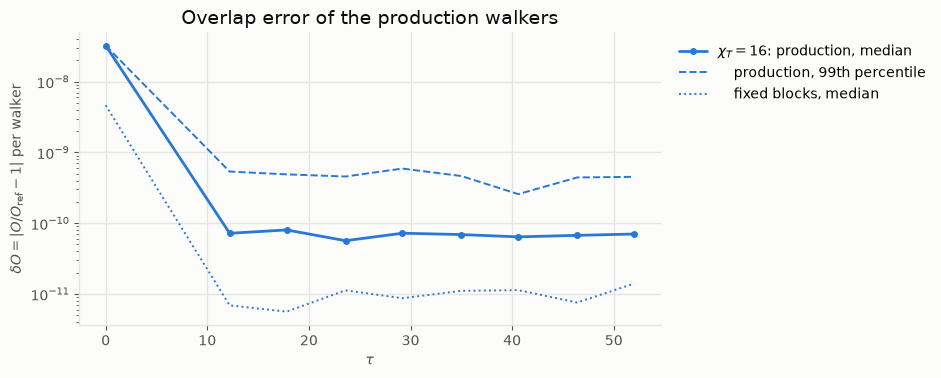

saved walker_overlap_error_data/overlap_error_sources.png


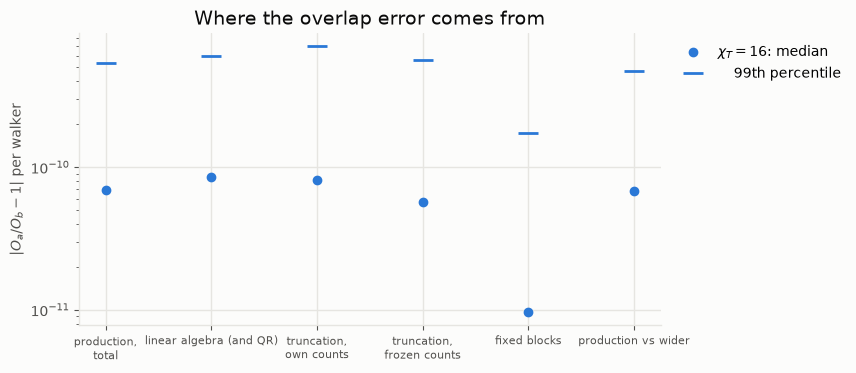

saved walker_overlap_error_data/overlap_error_vs_size.png


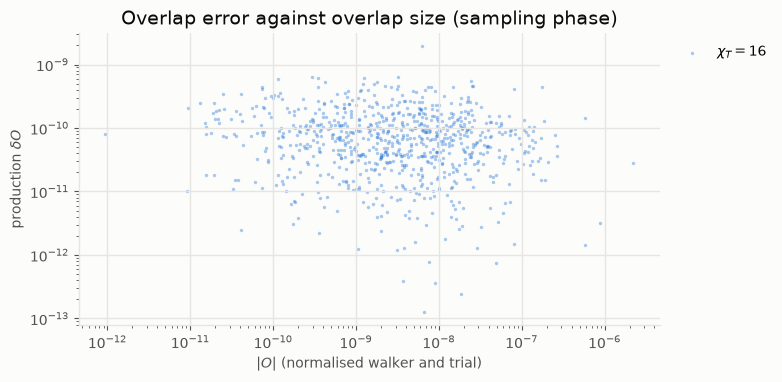

In [15]:
COLORS = {tag: PALETTE[i % len(PALETTE)] for i, tag in enumerate(RUNS)}
label = lambda tag: rf"$\chi_T={RUN[tag]['cfg']['DMRG_CHI_T']}$"
FLOOR = 1e-17

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for tag, run in RUN.items():
    total = np.maximum(r(run["O"]["prod"], run["O"]["full"]), FLOOR)
    n = run["O"]["wider"].shape[1]
    blocks = np.maximum(r(run["O"]["full"][:, :n], run["O"]["wider"]), FLOOR)
    ax.plot(run["tau"], np.median(total, 1), "o-", ms=4, color=COLORS[tag], label=f"{label(tag)}: production, median")
    ax.plot(run["tau"], np.percentile(total, 99, 1), "--", color=COLORS[tag], lw=1.4, label="    production, 99th percentile")
    ax.plot(run["tau"], np.median(blocks, 1), ":", color=COLORS[tag], lw=1.4, label="    fixed blocks, median")
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\delta O=|O/O_{\rm ref}-1|$ per walker")
ax.set_title("Overlap error of the production walkers")
ax.legend(**LEGEND)
save(fig, "overlap_error_tau"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(SOURCES))
for k, (tag, run) in enumerate(RUN.items()):
    vals = [np.maximum(source(run, a, b), FLOOR) for _, a, b in SOURCES]
    dx = 0.12 * (k - (len(RUN) - 1) / 2)
    ax.plot(x + dx, [np.median(v) for v in vals], "o", ms=6, color=COLORS[tag], label=f"{label(tag)}: median")
    ax.plot(x + dx, [np.percentile(v, 99) for v in vals], "_", ms=14, mew=2, color=COLORS[tag], label="    99th percentile")
ax.set_xticks(x, [s[0].replace(", ", ",\n") for s in SOURCES], fontsize=8)
ax.set_yscale("log")
ax.set_ylabel(r"$|O_a/O_b-1|$ per walker")
ax.set_title("Where the overlap error comes from")
ax.legend(**LEGEND)
save(fig, "overlap_error_sources"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for tag, run in RUN.items():
    ax.scatter(np.abs(run["O"]["full"][1:]).ravel(), np.maximum(r(run["O"]["prod"], run["O"]["full"])[1:], FLOOR).ravel(),
               s=6, alpha=0.4, lw=0, color=COLORS[tag], label=label(tag))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|O|$ (normalised walker and trial)"); ax.set_ylabel(r"production $\delta O$")
ax.set_title("Overlap error against overlap size (sampling phase)")
ax.legend(**LEGEND)
save(fig, "overlap_error_vs_size"); plt.show()